https://www.tensorflow.org/quantum/tutorials/mnist

In [5]:
import tensorflow as tf
import tensorflow_quantum as tfq

import cirq
import sympy
import numpy as np
import seaborn as sns
import collections

# visualization tools
%matplotlib inline
import matplotlib.pyplot as plt
from cirq.contrib.svg import SVGCircuit

### This for other data to be fed into the model, but in this case, the implementation has not been successful---------------------------------------------------------------------------------------------------------------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

In [60]:
# load numpy array from npy file
from numpy import load
# load both electron and gamma files 
dset = load('electron_image2.npy')
dset2 = load('gamma_image_moved_2.npy')

In [61]:
#put the target together
target0=np.zeros(dset.shape[0])
target1=np.ones(dset2.shape[0])
target=np.concatenate((target0, target1), axis=0)
#put the dataset together
data=np.concatenate((dset, dset2), axis=0)

In [62]:
import sklearn
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.20, random_state=2)  

In [63]:
from __future__ import print_function
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K

# input image dimensions
imgRows, imgCols = 55, 93
numChannels=1
samples=X_train.shape[0]
numClasses=2

#create x_train cause for CNN other shape is needed
x_train=X_train
x_test=X_test

#format: channels at the beginning
# x_train = x_train.reshape(x_train.shape[0], 1, img_rows, img_cols)
# x_test = x_test.reshape(x_test.shape[0], 1, img_rows, img_cols)
# input_shape = (1, img_rows, img_cols)

x_train = x_train.reshape(x_train.shape[0], imgRows, imgCols, 1)
x_test = x_test.reshape(x_test.shape[0], imgRows, imgCols, 1)
input_shape = (imgRows, imgCols, 1)

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')


In [64]:
# #put x_train with filters rgb (required to use keras applications for transfer learning)
# from keras import backend as K

# def grayscale_to_rgb(images, channel_axis=-1):
# #     images= K.expand_dims(images, axis=channel_axis)
#     tiling = [1] * 4    # 4 dimensions: B, H, W, C
#     tiling[channel_axis] *= 3
#     images= K.tile(images, tiling)
#     return images

# x_train_3=grayscale_to_rgb(x_train)
# x_test_3=grayscale_to_rgb(x_test)

In [3]:
#this is in case I want to resize the images for transfer learning for example.
x_train=tf.image.resize(x_train, [28,28], preserve_aspect_ratio=False)
x_test=tf.image.resize(x_test, [28,28],preserve_aspect_ratio=False)

NameError: name 'x_train' is not defined

In [66]:
len(x_train[0][0][0])

1

# -------------------------------------------

In [6]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


In [7]:
# Rescale the images from [0,255] to the [0.0,1.0] range.
x_train, x_test = x_train[..., np.newaxis]/255.0, x_test[..., np.newaxis]/255.0

print("Number of original training examples:", len(x_train))
print("Number of original test examples:", len(x_test))

Number of original training examples: 60000
Number of original test examples: 10000


In [8]:
len(x_train)

60000

In [9]:
def filter_36(x, y):
    keep = (y == 5) | (y == 6)
    x, y = x[keep], y[keep]
    y = y == 3
    return x,y

In [10]:
x_train, y_train = filter_36(x_train, y_train)
x_test, y_test = filter_36(x_test, y_test)

print("Number of filtered training examples:", len(x_train))
print("Number of filtered test examples:", len(x_test))

Number of filtered training examples: 11339
Number of filtered test examples: 1850


False


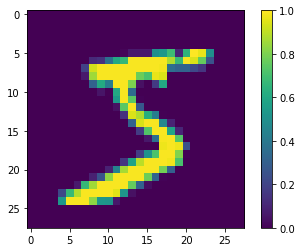

In [11]:
print(y_train[1])

plt.imshow(x_train[0, :, :, 0])
plt.colorbar()

In [12]:
x_train_small = tf.image.resize(x_train, (4,4)).numpy()
x_test_small = tf.image.resize(x_test, (4,4)).numpy()

False


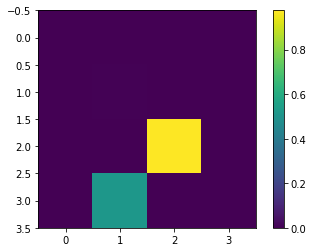

In [13]:
print(y_train[0])

plt.imshow(x_train_small[0,:,:,0])
plt.colorbar()

In [14]:
def remove_contradicting(xs, ys):
    mapping = collections.defaultdict(set)
    # Determine the set of labels for each unique image:
    for x,y in zip(xs,ys):
       mapping[tuple(x.flatten())].add(y)
    
    new_x = []
    new_y = []
    for x,y in zip(xs, ys):
      labels = mapping[tuple(x.flatten())]
      if len(labels) == 1:
          new_x.append(x)
          new_y.append(list(labels)[0])
      else:
          # Throw out images that match more than one label.
          pass
    
    num_5 = sum(1 for value in mapping.values() if True in value)
    num_6 = sum(1 for value in mapping.values() if False in value)
    num_both = sum(1 for value in mapping.values() if len(value) == 2)

    print("Number of unique images:", len(mapping.values()))
    print("Number of 5s: ", num_5)
    print("Number of 6s: ", num_6)
    print("Number of contradictory images: ", num_both)
    print()
    print("Initial number of examples: ", len(xs))
    print("Remaining non-contradictory examples: ", len(new_x))
    
    return np.array(new_x), np.array(new_y)

In [15]:
x_train_nocon, y_train_nocon = remove_contradicting(x_train_small, y_train)

Number of unique images: 10003
Number of 5s:  0
Number of 6s:  10003
Number of contradictory images:  0

Initial number of examples:  11339
Remaining non-contradictory examples:  11339


In [16]:
# #-----------------------------hecho por mi ----------------------------------------------------------
# x_train_bin, y_test_bin = x_train_small, y_train

In [17]:
THRESHOLD = 0.5

x_train_bin = np.array(x_train_nocon > THRESHOLD, dtype=np.float32)
x_test_bin = np.array(x_test_small > THRESHOLD, dtype=np.float32)

In [18]:
_ = remove_contradicting(x_train_bin, y_train_nocon)

Number of unique images: 182
Number of 5s:  0
Number of 6s:  182
Number of contradictory images:  0

Initial number of examples:  11339
Remaining non-contradictory examples:  11339


In [19]:
%%time
def convert_to_circuit(image):
    """Encode truncated classical image into quantum datapoint."""
    values = np.ndarray.flatten(image)
    qubits = cirq.GridQubit.rect(4, 4)
#     qubits = cirq.GridQubit.rect(5,5 )


    circuit = cirq.Circuit()
    for i, value in enumerate(values):
        if value:
            circuit.append(cirq.X(qubits[i]))
    return circuit


x_train_circ = [convert_to_circuit(x) for x in x_train_bin]
x_test_circ = [convert_to_circuit(x) for x in x_test_bin]

Wall time: 4.04 s


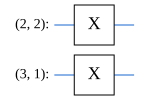

In [20]:
SVGCircuit(x_train_circ[0])

In [21]:
bin_img = x_train_bin[0,:,:,0]
indices = np.array(np.where(bin_img)).T
indices

array([[2, 2],
       [3, 1]], dtype=int64)

In [22]:
%%time
x_train_tfcirc = tfq.convert_to_tensor(x_train_circ)
x_test_tfcirc = tfq.convert_to_tensor(x_test_circ)

Wall time: 7.8 s


# QNN

In [23]:
class CircuitLayerBuilder():
    def __init__(self, data_qubits, readout):
        self.data_qubits = data_qubits
        self.readout = readout
    
    def add_layer(self, circuit, gate, prefix):
        for i, qubit in enumerate(self.data_qubits):
            symbol = sympy.Symbol(prefix + '-' + str(i))
            circuit.append(gate(qubit, self.readout)**symbol)

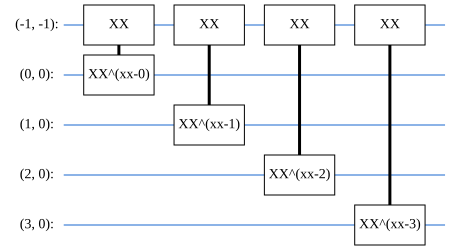

In [24]:
demo_builder = CircuitLayerBuilder(data_qubits = cirq.GridQubit.rect(4,1), 
                                   readout=cirq.GridQubit(-1,-1))

circuit = cirq.Circuit()
demo_builder.add_layer(circuit, gate = cirq.XX, prefix='xx')
SVGCircuit(circuit)

In [25]:
def create_quantum_model():
    """Create a QNN model circuit and readout operation to go along with it."""
    data_qubits = cirq.GridQubit.rect(4, 4)  # a 4x4 grid.
    readout = cirq.GridQubit(-1, -1)         # a single qubit at [-1,-1]
    circuit = cirq.Circuit()
    
    # Prepare the readout qubit.
    circuit.append(cirq.X(readout))
    circuit.append(cirq.H(readout))
    
    builder = CircuitLayerBuilder(
        data_qubits = data_qubits,
        readout=readout)

    # Then add layers (experiment by adding more).
    builder.add_layer(circuit, cirq.XX, "xx1")
    builder.add_layer(circuit, cirq.ZZ, "zz1")

    # Finally, prepare the readout qubit.
    circuit.append(cirq.H(readout))

    return circuit, cirq.Z(readout)

In [26]:
model_circuit, model_readout = create_quantum_model()

In [27]:
# Build the Keras model.
model = tf.keras.Sequential([
    # The input is the data-circuit, encoded as a tf.string
    tf.keras.layers.Input(shape=(), dtype=tf.string),
    # The PQC layer returns the expected value of the readout gate, range [-1,1].
    tfq.layers.PQC(model_circuit, model_readout),
])

In [28]:
y_train_hinge = 2.0*y_train_nocon-1.0
y_test_hinge = 2.0*y_test-1.0

In [29]:
def hinge_accuracy(y_true, y_pred):
    y_true = tf.squeeze(y_true) > 0.0
    y_pred = tf.squeeze(y_pred) > 0.0
    result = tf.cast(y_true == y_pred, tf.float32)

    return tf.reduce_mean(result)

In [30]:
model.compile(
    loss=tf.keras.losses.Hinge(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=[hinge_accuracy])

In [31]:
print(model.summary())

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
pqc (PQC)                    (None, 1)                 32        
Total params: 32
Trainable params: 32
Non-trainable params: 0
_________________________________________________________________
None


In [32]:
EPOCHS = 5
BATCH_SIZE = 32

NUM_EXAMPLES = 1000#len(x_train_tfcirc)

In [33]:
x_train_tfcirc_sub = x_train_tfcirc[:NUM_EXAMPLES]
y_train_hinge_sub = y_train_hinge[:NUM_EXAMPLES]

In [34]:
qnn_history = model.fit(
      x_train_tfcirc_sub, y_train_hinge_sub,
      batch_size=32,
      epochs=EPOCHS,
      verbose=1,
      validation_data=(x_test_tfcirc, y_test_hinge))

qnn_results = model.evaluate(x_test_tfcirc, y_test)

Train on 1000 samples, validate on 1850 samples
Epoch 1/5
1000/1000 [==============================] - 1091s 1s/sample - loss: 0.9240 - hinge_accuracy: 0.8516 - val_loss: 0.8844 - val_hinge_accuracy: 0.9223
Epoch 2/5
1000/1000 [==============================] - 1112s 1s/sample - loss: 0.8166 - hinge_accuracy: 0.9609 - val_loss: 0.7484 - val_hinge_accuracy: 0.9632
Epoch 3/5
1000/1000 [==============================] - 1079s 1s/sample - loss: 0.6401 - hinge_accuracy: 0.9834 - val_loss: 0.5439 - val_hinge_accuracy: 0.9865
Epoch 4/5
1000/1000 [==============================] - 1101s 1s/sample - loss: 0.4255 - hinge_accuracy: 0.9941 - val_loss: 0.3361 - val_hinge_accuracy: 0.9925
Epoch 5/5
1850/1850 [==============================] - 35s 19ms/sample - loss: 0.1861 - hinge_accuracy: 0.9935


# NN

In [35]:
def create_classical_model():
    # A simple model based off LeNet from https://keras.io/examples/mnist_cnn/
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Conv2D(32, [3, 3], activation='relu', input_shape=(28,28,1)))
    model.add(tf.keras.layers.Conv2D(64, [3, 3], activation='relu'))
    model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(tf.keras.layers.Dropout(0.25))
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(128, activation='relu'))
    model.add(tf.keras.layers.Dropout(0.5))
    model.add(tf.keras.layers.Dense(1))
    return model


model = create_classical_model()
model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 24, 24, 64)        18496     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 12, 12, 64)        0         
_________________________________________________________________
dropout (Dropout)            (None, 12, 12, 64)        0         
_________________________________________________________________
flatten (Flatten)            (None, 9216)              0         
_________________________________________________________________
dense (Dense)                (None, 128)               1179776   
_________________________________________________________________
dropout_1 (Dropout)          (None, 128)              

In [36]:
model.fit(x_train,
          y_train,
          batch_size=128,
          epochs=5,
          verbose=1,
          validation_data=(x_test, y_test))

cnn_results = model.evaluate(x_test, y_test)

Train on 11339 samples, validate on 1850 samples
Epoch 1/5
11339/11339 [==============================] - 19s 2ms/sample - loss: 0.0110 - accuracy: 1.0000 - val_loss: 2.7698e-13 - val_accuracy: 1.0000
Epoch 2/5
11339/11339 [==============================] - 20s 2ms/sample - loss: 2.3647e-12 - accuracy: 1.0000 - val_loss: 2.7495e-13 - val_accuracy: 1.0000
Epoch 3/5
11339/11339 [==============================] - 24s 2ms/sample - loss: 3.5284e-12 - accuracy: 1.0000 - val_loss: 2.7495e-13 - val_accuracy: 1.0000
Epoch 4/5
11339/11339 [==============================] - 20s 2ms/sample - loss: 1.0148e-12 - accuracy: 1.0000 - val_loss: 2.7495e-13 - val_accuracy: 1.0000
Epoch 5/5
1850/1850 [==============================] - 1s 517us/sample - loss: 2.7495e-13 - accuracy: 1.0000


In [37]:
def create_fair_classical_model():
    # A simple model based off LeNet from https://keras.io/examples/mnist_cnn/
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Flatten(input_shape=(4,4,1)))
    model.add(tf.keras.layers.Dense(2, activation='relu'))
    model.add(tf.keras.layers.Dense(1))
    return model


model = create_fair_classical_model()
model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_1 (Flatten)          (None, 16)                0         
_________________________________________________________________
dense_2 (Dense)              (None, 2)                 34        
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 3         
Total params: 37
Trainable params: 37
Non-trainable params: 0
_________________________________________________________________


In [38]:
model.fit(x_train_bin,
          y_train_nocon,
          batch_size=128,
          epochs=5,
          verbose=2,
          validation_data=(x_test_bin, y_test))

fair_nn_results = model.evaluate(x_test_bin, y_test)

Train on 11339 samples, validate on 1850 samples
Epoch 1/5
11339/11339 - 0s - loss: 0.6793 - accuracy: 0.9992 - val_loss: 0.6540 - val_accuracy: 1.0000
Epoch 2/5
11339/11339 - 0s - loss: 0.6328 - accuracy: 1.0000 - val_loss: 0.6111 - val_accuracy: 1.0000
Epoch 3/5
11339/11339 - 0s - loss: 0.5918 - accuracy: 1.0000 - val_loss: 0.5725 - val_accuracy: 1.0000
Epoch 4/5
11339/11339 - 0s - loss: 0.5550 - accuracy: 1.0000 - val_loss: 0.5372 - val_accuracy: 1.0000
Epoch 5/5
11339/11339 - 0s - loss: 0.5209 - accuracy: 1.0000 - val_loss: 0.5044 - val_accuracy: 1.0000
1850/1850 [==============================] - 0s 23us/sample - loss: 0.5044 - accuracy: 1.0000


# Comparison

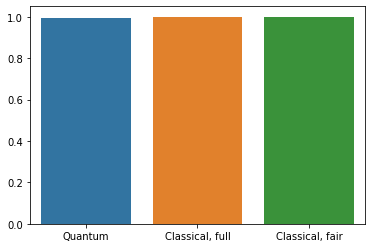

In [39]:
qnn_accuracy = qnn_results[1]
cnn_accuracy = cnn_results[1]
fair_nn_accuracy = fair_nn_results[1]

sns.barplot(["Quantum", "Classical, full", "Classical, fair"],
            [qnn_accuracy, cnn_accuracy, fair_nn_accuracy])

In [42]:
# libraries
import numpy as np
import matplotlib.pyplot as plt
 
# Make a fake dataset
height = [qnn_accuracy, cnn_accuracy, fair_nn_accuracy]
bars = ("Quantum", "Classical, full", "Classical, fair")
y_pos = np.arange(len(bars))


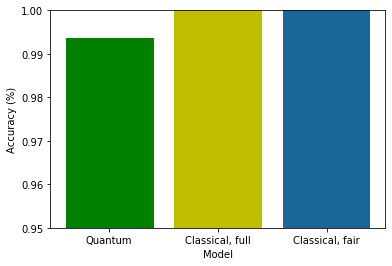

In [63]:
barlist=plt.bar(y_pos, height, color=(0.1, 0.4, 0.6))
plt.xticks(y_pos, bars)
plt.ylim(0.95,1)
plt.ylabel('Accuracy (%)')
plt.xlabel('Model')
barlist[0].set_color('g')
barlist[1].set_color('y')
plt.show()
